# # 🔍 SHAP Explainability — XGBoost Death Score Model
#
# ## Plan
#
# We answer 4 questions with SHAP, going from global to local:
#
# | # | Question | SHAP Tool | What it shows |
# |---|----------|-----------|---------------|
# | 1 | **Which features matter most overall?** | Summary bar plot | Mean absolute SHAP per feature |
# | 2 | **How does each feature push predictions?** | Beeswarm plot | Direction + magnitude per data point |
# | 3 | **How do features interact?** | Dependence plots | Feature value vs SHAP value, colored by interaction |
# | 4 | **Why did the model predict X for this company?** | Waterfall plots | Per-company feature contributions |
#
# Then we build actionable takeaways for the capstone presentation.


In [1]:
#  1  Setup & Train Best Model

#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
print(f'SHAP version: {shap.__version__}')

#
df = pd.read_csv('../raw_data/features_enriched_with_death_score.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nTarget distribution:')
print(df['target_death_score'].value_counts().sort_index())

#
num_features = [
    'funding_total_usd', 'funding_rounds',
    'seed', 'venture', 'debt_financing', 'angel', 'grant', 'private_equity',
    'round_A', 'round_B', 'round_C', 'round_D', 'round_E',
    'avg_raised_per_round', 'age_first_funding_days',
    'has_multiple_rounds', 'funding_span_days', 'avg_years_between_rounds',
    'time_since_last_funding'
]
cat_features = ['region_group', 'industry_group']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

mask = df['target_death_score'].notna()
X = df[mask][num_features + cat_features]
y = df[mask]['target_death_score'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp = preprocessor.transform(X_test)

# Get feature names after OHE
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
feature_names = num_features + ohe_names
print(f'Total features after preprocessing: {len(feature_names)}')

#
# Train best model (tuned params from GridSearch)
model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    base_score=0.5,
    eval_metric='logloss',
    random_state=SEED,
    use_label_encoder=False,
)
model.fit(X_train_pp, y_train)

y_pred = model.predict(X_test_pp)
y_proba = model.predict_proba(X_test_pp)[:, 1]
print(f'Test AUC:  {roc_auc_score(y_test, y_proba):.4f}')
print(f'Test F1m:  {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["closed", "survived"])}')

SHAP version: 0.49.1
Loaded: 43,212 rows x 41 columns

Target distribution:
target_death_score
0    22506
1    20706
Name: count, dtype: int64
Total features after preprocessing: 39


Test AUC:  0.8736
Test F1m:  0.8321

              precision    recall  f1-score   support

      closed       0.90      0.77      0.83      4502
    survived       0.78      0.91      0.84      4141

    accuracy                           0.83      8643
   macro avg       0.84      0.84      0.83      8643
weighted avg       0.84      0.83      0.83      8643



In [2]:
pip install xgboost==1.7.6

Note: you may need to restart the kernel to use updated packages.


In [3]:
#  2 Compute SHAP Values

#
explainer = shap.TreeExplainer(model)

# Compute on test set
shap_values = explainer.shap_values(X_test_pp)

# Wrap in a DataFrame for readable plots
X_test_display = pd.DataFrame(X_test_pp, columns=feature_names)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Expected value (base rate log-odds): {explainer.expected_value:.4f}')

SHAP values shape: (8643, 39)
Expected value (base rate log-odds): -0.1038


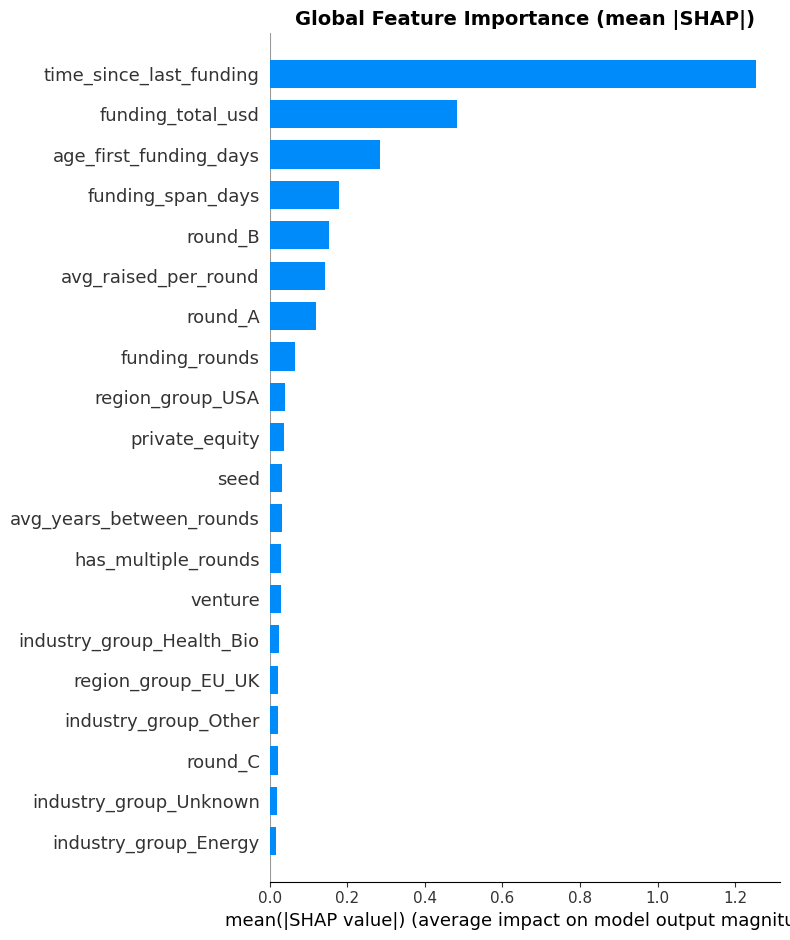

In [4]:
#  3  Global Feature Importance — Bar Plot

# Question: Which features matter most overall?

# The bar plot shows mean |SHAP| per feature — the average magnitude of each
# feature's impact on predictions, regardless of direction.

#
shap.summary_plot(shap_values, X_test_display, plot_type='bar', show=False,
                  max_display=20)
plt.title('Global Feature Importance (mean |SHAP|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


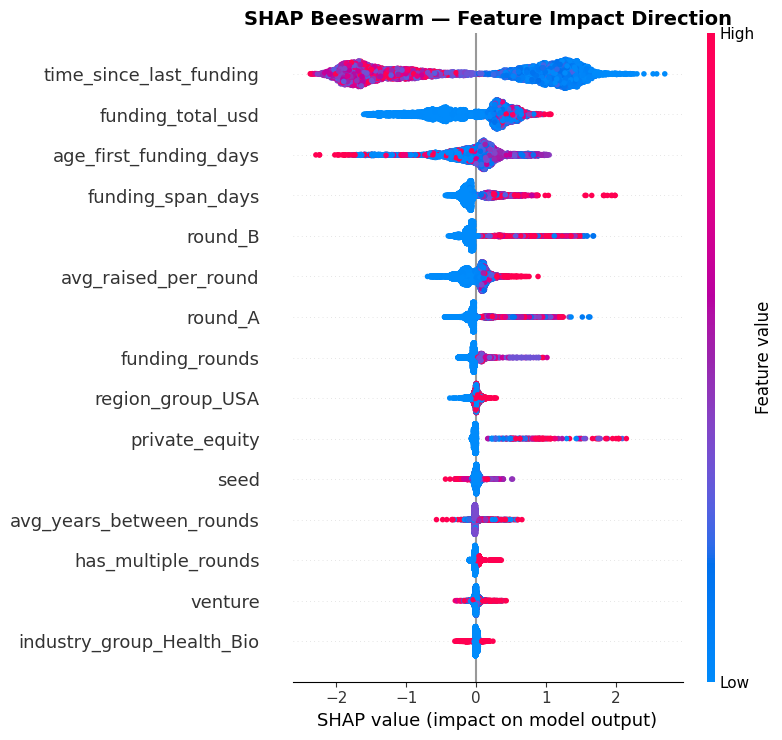

In [5]:
# 4  Beeswarm Plot — Direction + Magnitude

# Question: How does each feature push predictions?

# Each dot is one company. X-axis = SHAP value (positive = pushes toward survived,
# negative = pushes toward closed). Color = feature value (red = high, blue = low).

#
shap.summary_plot(shap_values, X_test_display, show=False, max_display=15)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

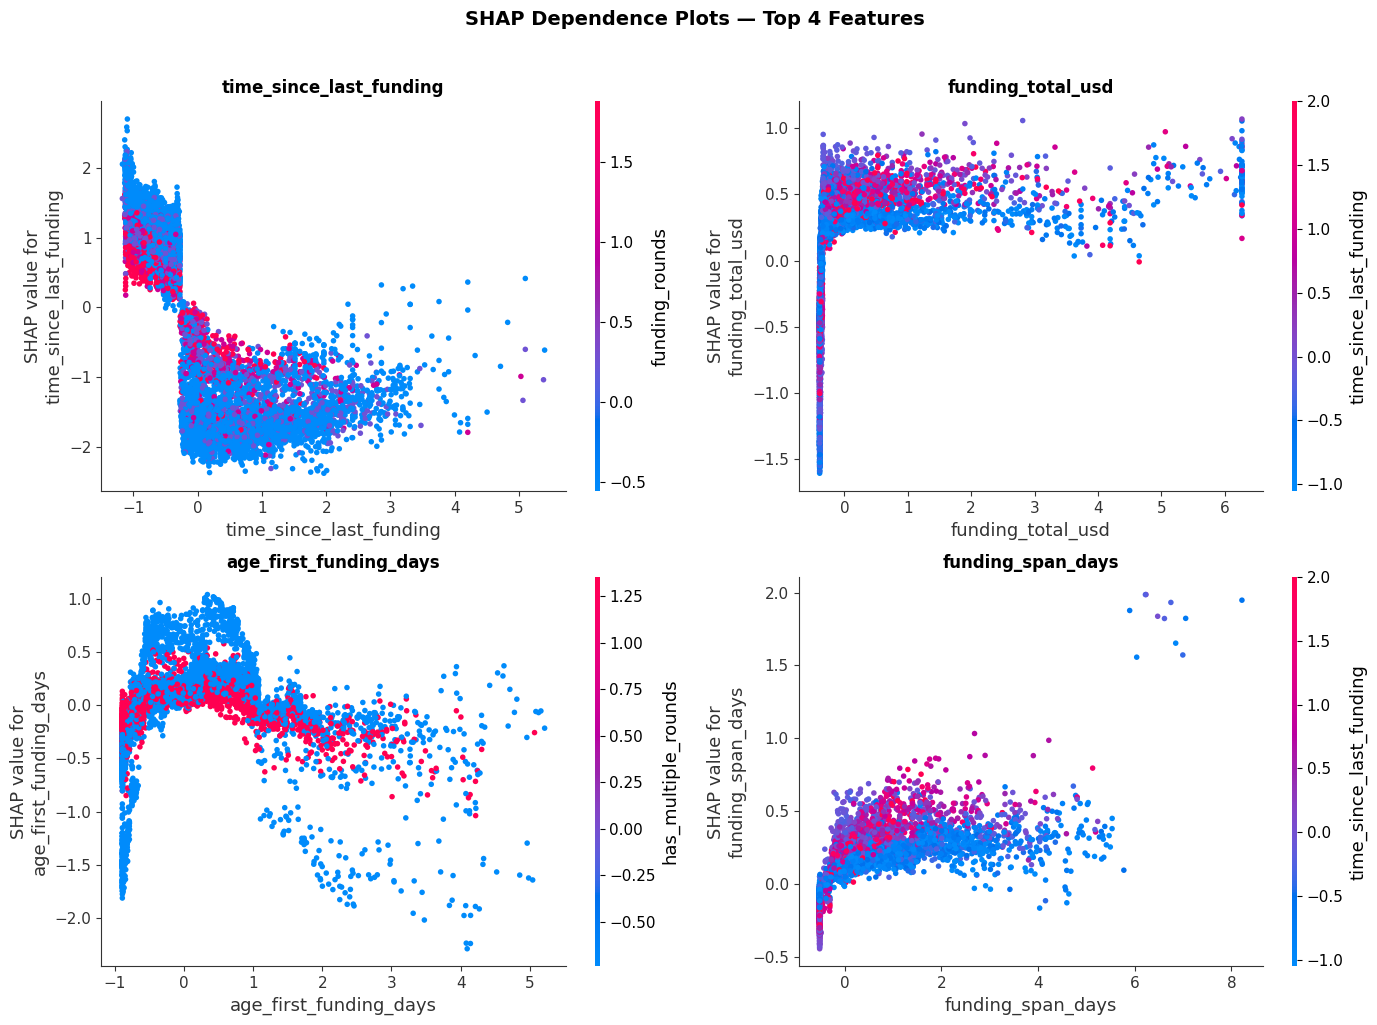

In [6]:
# 5  Dependence Plots — Feature Interactions

# Question: How do specific features interact?

# Shows the relationship between a feature's value and its SHAP impact.
# SHAP auto-selects the strongest interaction feature for coloring.


# Top 4 most important features
top_features_idx = np.argsort(np.abs(shap_values).mean(axis=0))[::-1][:4]
top_feature_names = [feature_names[i] for i in top_features_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, fname in zip(axes.flatten(), top_feature_names):
    idx = feature_names.index(fname)
    shap.dependence_plot(idx, shap_values, X_test_display,
                         feature_names=feature_names, ax=ax, show=False)
    ax.set_title(f'{fname}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


  High confidence SURVIVED
  Predicted: survived (98.9%)
  Actual:    survived


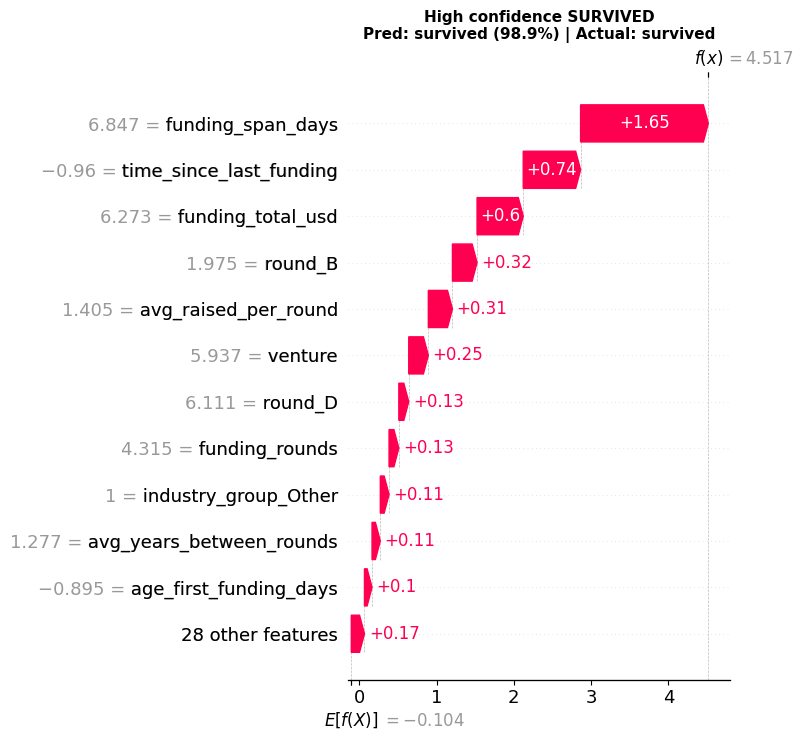


  High confidence CLOSED
  Predicted: closed (99.2%)
  Actual:    closed


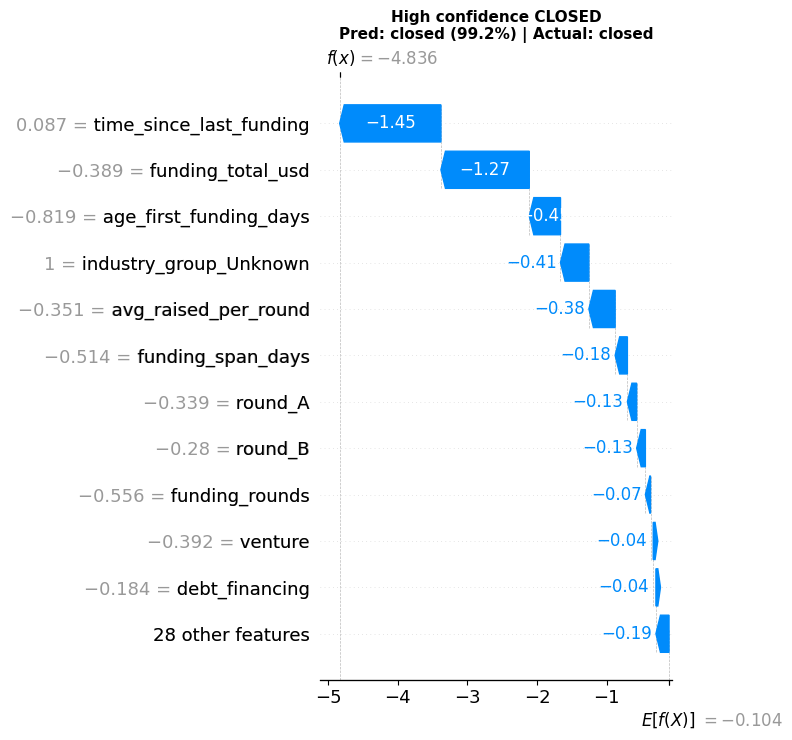


  BORDERLINE case
  Predicted: survived (50.1%)
  Actual:    closed


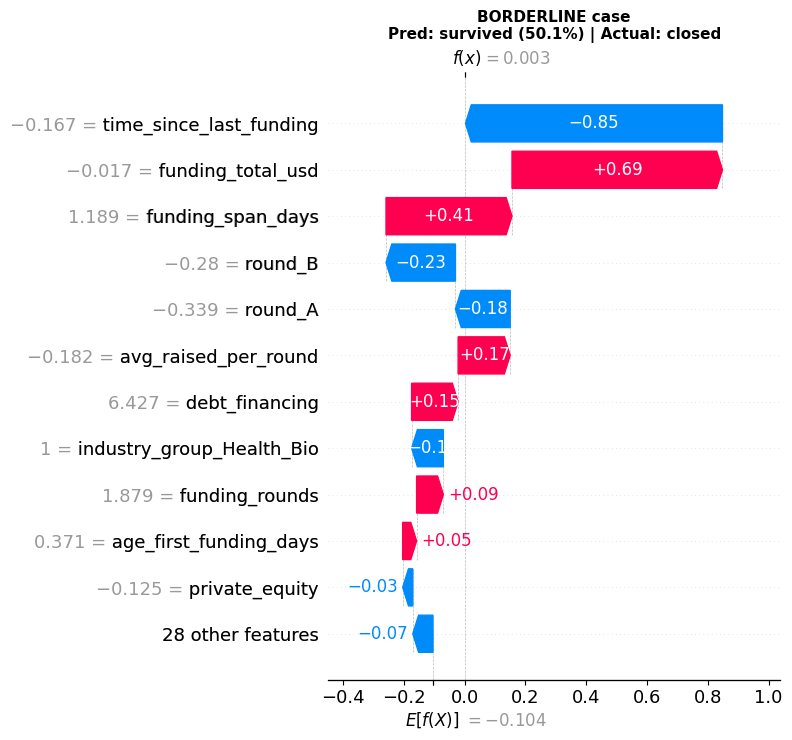

In [7]:
#  6 Individual Predictions — Waterfall Plots

# Question: Why did the model predict X for this specific company?

# We pick example companies from the test set:
# - A company predicted to survive with high confidence
# - A company predicted to die with high confidence
# - A borderline case

# Find interesting examples — CORRECT predictions only
proba_test = model.predict_proba(X_test_pp)[:, 1]
pred_labels = (proba_test > 0.5).astype(int)
correct = pred_labels == y_test

# High confidence survived (correct)
survived_correct = np.where(correct & (y_test == 1))[0]
idx_survived = survived_correct[np.argmax(proba_test[survived_correct])]

# High confidence closed (correct)
closed_correct = np.where(correct & (y_test == 0))[0]
idx_closed = closed_correct[np.argmin(proba_test[closed_correct])]

# Borderline (closest to 0.5)
idx_borderline = np.argmin(np.abs(proba_test - 0.5))

examples = {
    'High confidence SURVIVED': idx_survived,
    'High confidence CLOSED': idx_closed,
    'BORDERLINE case': idx_borderline,
}

for title, idx in examples.items():
    prob = proba_test[idx]
    actual = y_test[idx]
    actual_label = 'survived' if actual == 1 else 'closed'
    pred_label = 'survived' if prob > 0.5 else 'closed'
    confidence = prob if prob > 0.5 else 1 - prob

    print(f'\n{"="*60}')
    print(f'  {title}')
    print(f'  Predicted: {pred_label} ({confidence:.1%})')
    print(f'  Actual:    {actual_label}')
    print(f'{"="*60}')

    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_pp[idx],
        feature_names=feature_names,
    )

    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f'{title}\nPred: {pred_label} ({confidence:.1%}) | Actual: {actual_label}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

Misclassified: 1449 / 8643 (16.8%)
  False positives (predicted survived, was closed): 1057
  False negatives (predicted closed, was survived): 392

Worst false positive: predicted survived at 98.2%, actually closed


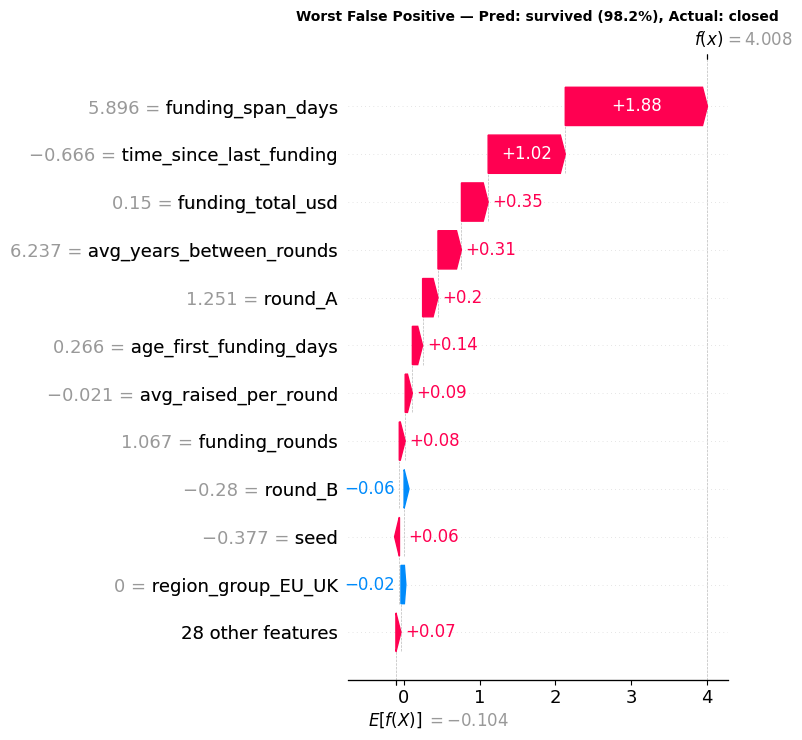


Worst false negative: predicted closed at 1.6%, actually survived


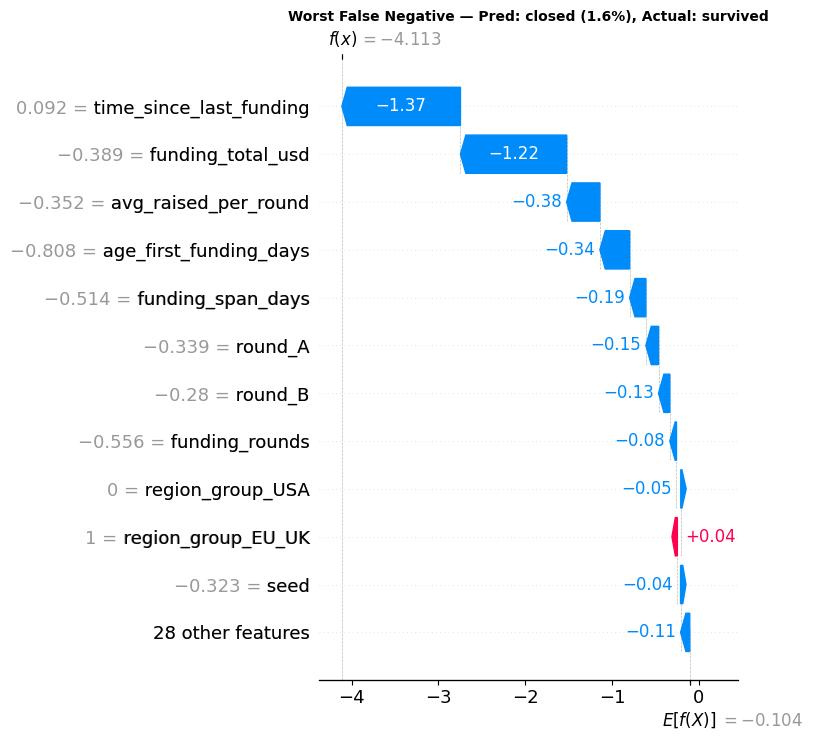

In [8]:
#  7 Misclassification Analysis

# Question: Where does the model fail, and what does SHAP say about those cases?

# Find misclassified examples
pred_labels = (proba_test > 0.5).astype(int)
wrong = np.where(pred_labels != y_test)[0]
print(f'Misclassified: {len(wrong)} / {len(y_test)} ({len(wrong)/len(y_test)*100:.1f}%)')

# False positives: predicted survived, actually closed
fp = wrong[y_test[wrong] == 0]
# False negatives: predicted closed, actually survived
fn = wrong[y_test[wrong] == 1]
print(f'  False positives (predicted survived, was closed): {len(fp)}')
print(f'  False negatives (predicted closed, was survived): {len(fn)}')

# Show SHAP for a confident false positive and false negative
if len(fp) > 0:
    # Most confident wrong survival prediction
    fp_probs = proba_test[fp]
    fp_worst = fp[np.argmax(fp_probs)]
    print(f'\nWorst false positive: predicted survived at {proba_test[fp_worst]:.1%}, actually closed')
    explanation = shap.Explanation(
        values=shap_values[fp_worst],
        base_values=explainer.expected_value,
        data=X_test_pp[fp_worst],
        feature_names=feature_names,
    )
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f'Worst False Positive — Pred: survived ({proba_test[fp_worst]:.1%}), Actual: closed',
              fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

if len(fn) > 0:
    fn_probs = proba_test[fn]
    fn_worst = fn[np.argmin(fn_probs)]
    print(f'\nWorst false negative: predicted closed at {proba_test[fn_worst]:.1%}, actually survived')
    explanation = shap.Explanation(
        values=shap_values[fn_worst],
        base_values=explainer.expected_value,
        data=X_test_pp[fn_worst],
        feature_names=feature_names,
    )
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f'Worst False Negative — Pred: closed ({proba_test[fn_worst]:.1%}), Actual: survived',
              fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

Top 10 features by importance:
                feature  mean_abs_shap  mean_shap       direction
time_since_last_funding       1.252545  -0.094429  favors closure
      funding_total_usd       0.483281  -0.069028  favors closure
 age_first_funding_days       0.285661  -0.030975  favors closure
      funding_span_days       0.177695   0.000100 favors survival
                round_B       0.153501  -0.039591  favors closure
   avg_raised_per_round       0.142414  -0.017893  favors closure
                round_A       0.120266  -0.008300  favors closure
         funding_rounds       0.066481   0.006010 favors survival
       region_group_USA       0.040918  -0.002288  favors closure
         private_equity       0.038141   0.001348 favors survival


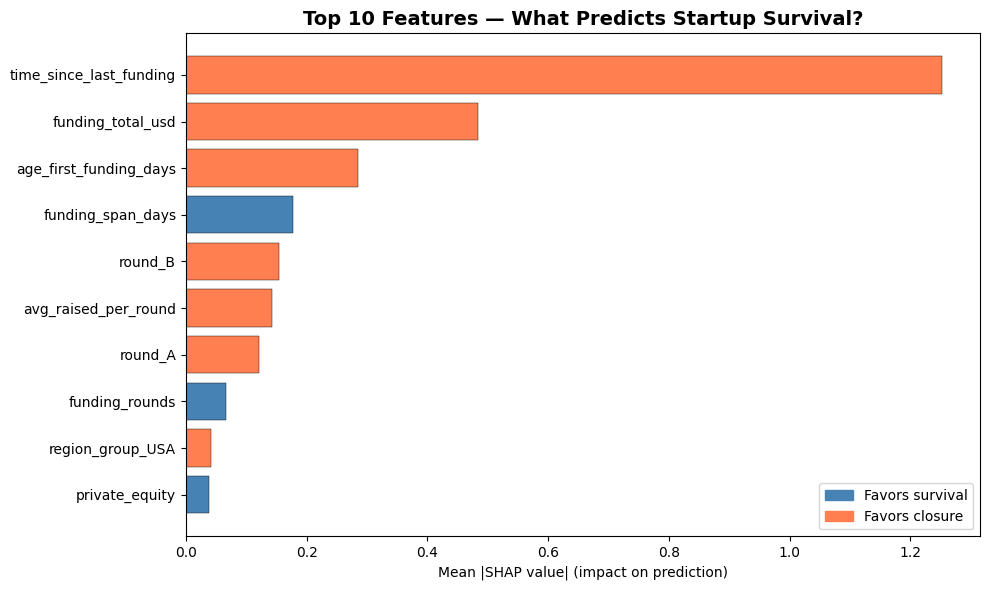

In [9]:
#  8 Capstone-Ready Summary Table

#
# Build a clean summary of feature impacts
mean_abs_shap = np.abs(shap_values).mean(axis=0)
mean_shap = shap_values.mean(axis=0)

summary = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap,
    'mean_shap': mean_shap,
    'direction': ['favors survival' if s > 0 else 'favors closure' for s in mean_shap],
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('Top 10 features by importance:')
print(summary.head(10).to_string(index=False))

#
# Clean bar chart for the presentation
top10 = summary.head(10).sort_values('mean_abs_shap')
colors = ['steelblue' if d == 'favors survival' else 'coral' for d in top10['direction']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10['feature'], top10['mean_abs_shap'], color=colors, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Mean |SHAP value| (impact on prediction)')
ax.set_title('Top 10 Features — What Predicts Startup Survival?', fontsize=14, fontweight='bold')

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Favors survival'),
    mpatches.Patch(color='coral', label='Favors closure'),
], loc='lower right')

plt.tight_layout()
plt.show()